Accuracy: 0.8336520076481836

Confusion Matrix:
[[1081  131]
 [ 130  227]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1212
           1       0.63      0.64      0.63       357

    accuracy                           0.83      1569
   macro avg       0.76      0.76      0.76      1569
weighted avg       0.83      0.83      0.83      1569


Feature Importance:
        Feature  Importance
15     poutcome    0.526043
11     duration    0.304830
6       housing    0.085405
13        pdays    0.056073
10        month    0.007518
9   day_of_week    0.005771
7          loan    0.004897
5       balance    0.004568
1           job    0.002635
14     previous    0.001670
12     campaign    0.000588
3     education    0.000000
4       default    0.000000
0           age    0.000000
2       marital    0.000000
8       contact    0.000000


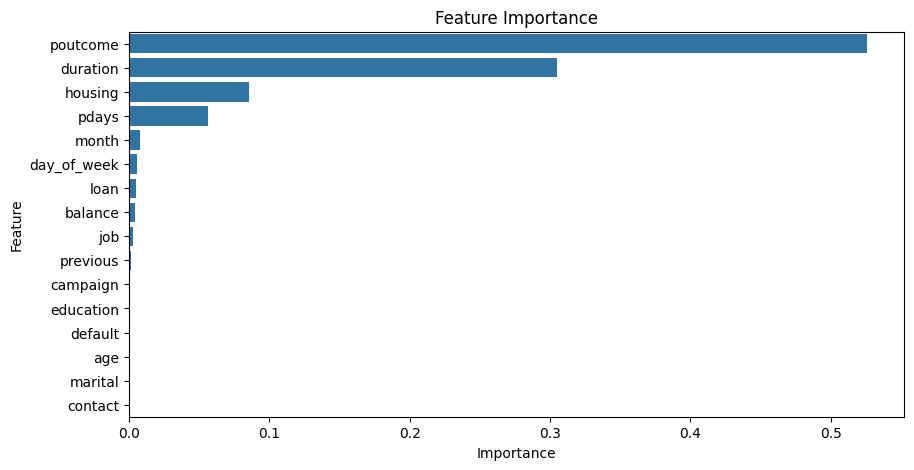

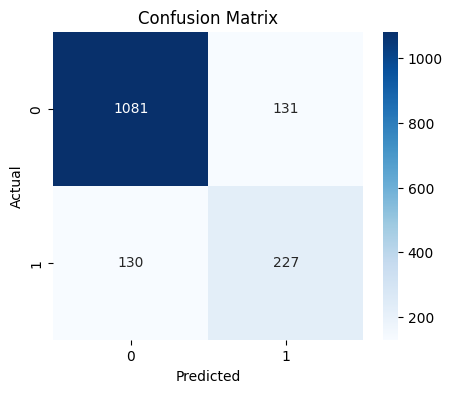

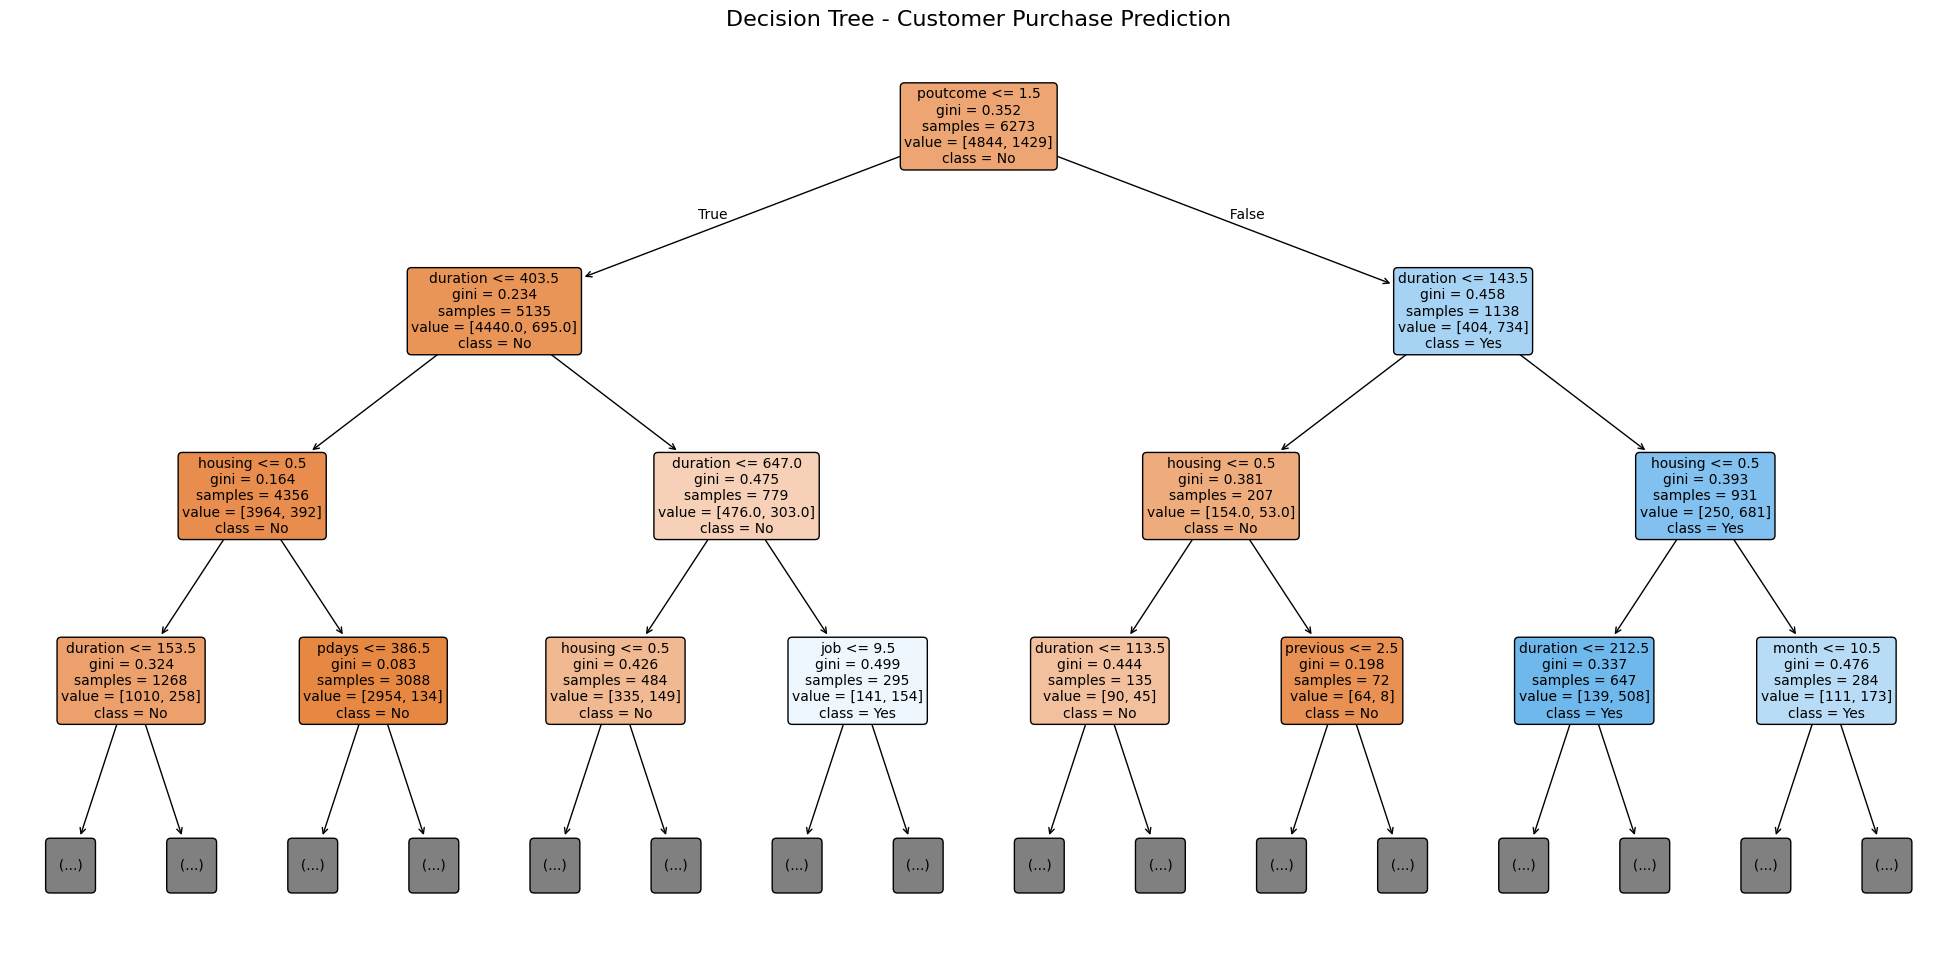

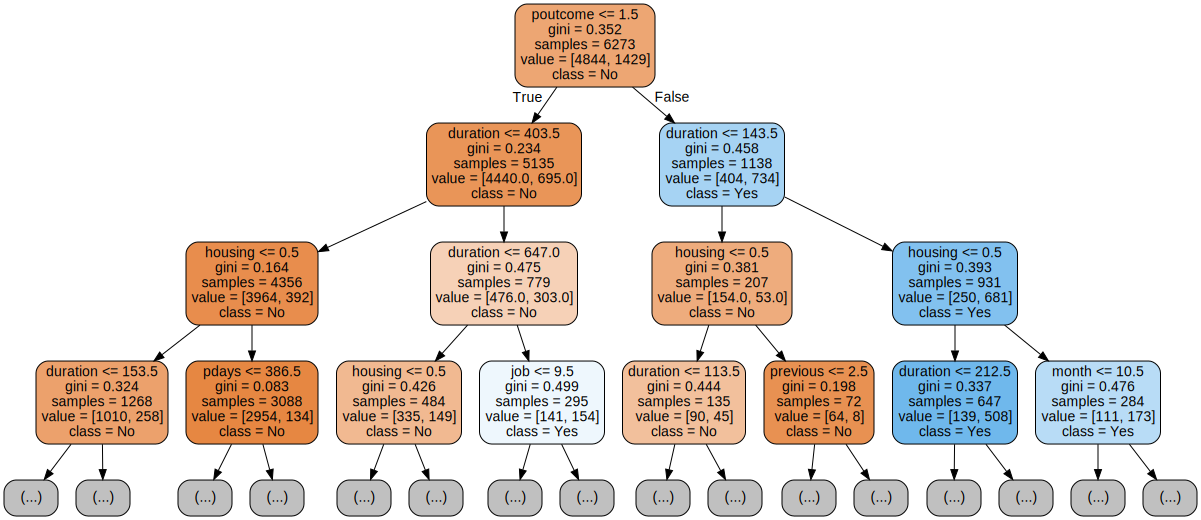

In [ ]:
# =========================================
# STEP 1: INSTALL & IMPORT LIBRARIES
# =========================================
!pip install ucimlrepo seaborn graphviz

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import graphviz


# =========================================
# STEP 2: LOAD DATASET
# =========================================
bank = fetch_ucirepo(id=222)

X = bank.data.features
y = bank.data.targets

df = pd.concat([X, y], axis=1)

df = df.dropna()


# =========================================
# STEP 3: ENCODING
# =========================================
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


# =========================================
# STEP 4: SPLIT DATA
# =========================================
X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================================
# STEP 5: TRAIN MODEL
# =========================================
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)


# =========================================
# STEP 6: PREDICTIONS
# =========================================
y_pred = dt_model.predict(X_test)


# =========================================
# STEP 7: EVALUATION
# =========================================
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# =========================================
# STEP 8: FEATURE IMPORTANCE (IMPORTANT FOR LINKEDIN)
# =========================================
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(10,5))
sns.barplot(x=importance["Importance"], y=importance["Feature"])
plt.title("Feature Importance")
plt.show()


# =========================================
# STEP 9: CONFUSION MATRIX (CLEAN VISUAL)
# =========================================
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================================
# STEP 10: CLEAN DECISION TREE (LINKEDIN STYLE)
# =========================================
plt.figure(figsize=(25,12))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.title("Decision Tree - Customer Purchase Prediction", fontsize=16)
plt.show()


# =========================================
# STEP 11: PROFESSIONAL GRAPHVIZ TREE (OPTIONAL BUT BEST)
# =========================================
dot_data = export_graphviz(
    dt_model,
    out_file=None,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=3
)

graph = graphviz.Source(dot_data)
graph

In [ ]:
graph.render(filename="decision_tree", format="png", cleanup=True)

'decision_tree.png'

In [ ]:
from google.colab import files
files.download('decision_tree.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This will save the decision tree visualization as `decision_tree.png` and open it. You can change `format='png'` to `format='pdf'` if you prefer a PDF output.